# Football Match Prediction — ML Experiment Runner
Trains XGBoost & NeuralNetwork with GridSearchCV, tracks via MLflow, saves best models.

#### 1. Imports

In [46]:
#!pip install mlflow xgboost
import os
import warnings
from pathlib import Path

import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier


warnings.filterwarnings('ignore')
print('✓ Imports done')

✓ Imports done


#### 2. Config

In [47]:
# ── Experiment settings ────────────────────────────────────────────────────────
FEATURE_VERSION    = 'v3'           # bump when features change
TEST_SIZE          = 0.2
N_CV_SPLITS        = 5
MODEL_SAVE_DIR     = Path('../saved_models')
MLFLOW_TRACKING_URI = 'file:///C:/mlflow_tracking'
MLFLOW_EXPERIMENT  = 'football_prediction'

# Class balance: 'balanced', 'custom', or None
CLASS_WEIGHT_STRATEGY = 'balanced'
CUSTOM_CLASS_WEIGHTS  = {0: 1.0, 1: 3.0, 2: 1.0}  # used only if strategy='custom'

# ── Active feature sets (comment out to disable) ───────────────────────────────
ACTIVE_FEATURE_SETS = [
    #'Raw Only',
    'Raw + Ratio',
]

print('✓ Config set')

✓ Config set


In [48]:
%run feature_engineering_v2.ipynb

✓ build_master defined
  home_team: (12303, 143)
  away_team: (12303, 143)
  home_player: (237079, 307)
  away_player: (236132, 307)
  scores: (12303, 4)
✓ build_master: 12303 rows × 135 cols
✓ Feature sets active: []
✓ feature_engineering_v2 loaded — master_df: (12303, 135), feature sets: []


In [49]:
%run van_utility_function.ipynb

#### 4. Feature Sets & Model Registry

In [50]:
non_features   = {'ID', 'target'}
home_away_cols = [c for c in master_df.columns if c[:5] in ('HOME_', 'AWAY_') and c not in non_features]
diff_cols      = [c for c in master_df.columns if c.startswith('DIFF_')]
ratio_cols     = [c for c in master_df.columns if c.startswith('RATIO_')]

ALL_FEATURE_SETS = {
    'Raw Only':        home_away_cols,
    'Raw + Diff':      home_away_cols + diff_cols,
    'Raw + Ratio':     home_away_cols + ratio_cols,
    'All':             home_away_cols + diff_cols + ratio_cols,
    'Engineered Only': diff_cols + ratio_cols,
}

feature_experiments = {k: v for k, v in ALL_FEATURE_SETS.items() if k in ACTIVE_FEATURE_SETS}
print(f'✓ Feature sets: {list(feature_experiments.keys())}')
for name, cols in feature_experiments.items():
    print(f'  {name}: {len(cols)} features')

✓ Feature sets: ['Raw + Ratio']
  Raw + Ratio: 98 features


In [51]:
# ── Class weights ──────────────────────────────────────────────────────────────
classes     = np.array([0, 1, 2])
cw_balanced = compute_class_weight('balanced', classes=classes,
                                   y=master_df['target'].astype(int))
cw_dict     = dict(zip(classes, cw_balanced))
print(f'Balanced class weights: {cw_dict}')

weight_dict = (
    cw_dict                if CLASS_WEIGHT_STRATEGY == 'balanced'
    else CUSTOM_CLASS_WEIGHTS if CLASS_WEIGHT_STRATEGY == 'custom'
    else None
)

# ── Model registry ─────────────────────────────────────────────────────────────
MODEL_REGISTRY = {
    # 'XGBoost': {
    #     'model': XGBClassifier(
    #         eval_metric='mlogloss', random_state=42,
    #         # class_weight not supported — sample_weight passed in fit() below
    #     ),
    #     'params': {
    #     'clf__learning_rate':    [0.01, 0.05],
    #     'clf__n_estimators':     [200, 500],
    #     'clf__max_depth':        [3, 4],          # shallower trees
    #     'clf__subsample':        [0.6, 0.8],
    #     'clf__colsample_bytree': [0.6, 0.8],
    #     'clf__min_child_weight': [5, 10, 20],     # harder to split
    #     'clf__reg_lambda':       [1.0, 5.0, 10.0],  # L2 regularization
    #     'clf__reg_alpha':        [0.0, 0.5, 1.0],   # L1 regularization
    #     'clf__gamma':            [0.0, 0.1, 0.5],   # min gain to split
    #     },
    # },
    'NeuralNetwork': {
        'model': MLPClassifier(max_iter=1000, random_state=42, early_stopping=True),
        # MLPClassifier has no class_weight — class imbalance handled via weights above
        'params': {
            'clf__hidden_layer_sizes': [(64, 32), (32, 16), (16,)],
            'clf__alpha':              [0.1, 1.0, 10.0],
            'clf__activation':         ['relu'],
        },
    },
    # ['LightGBM'] = {
    # 'model': LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1),
    # 'params': {
    #     'clf__learning_rate':    [0.01, 0.05],
    #     'clf__n_estimators':     [200, 500],
    #     'clf__max_depth':        [4, 6],
    #     'clf__num_leaves':       [15, 31],
    #     'clf__min_child_samples':[20, 50],
    #     'clf__reg_alpha':        [0.0, 0.5],
    #     'clf__reg_lambda':       [1.0, 5.0],
    #     'clf__subsample':        [0.7, 0.9],
    #     'clf__colsample_bytree': [0.7, 0.9],
    #     },
    # }
}

print(f'✓ Models registered: {list(MODEL_REGISTRY.keys())}')

Balanced class weights: {np.int64(0): np.float64(1.0904014889657005), np.int64(1): np.float64(1.2871939736346516), np.int64(2): np.float64(0.7656833457804332)}
✓ Models registered: ['NeuralNetwork']


In [52]:
print(feature_experiments)  # if this is {}, that's your bug
print(ACTIVE_FEATURE_SETS)

{'Raw + Ratio': ['HOME_TEAM_SHOTS_ON_TARGET_5_last_match_sum', 'HOME_TEAM_SHOTS_TOTAL_5_last_match_sum', 'HOME_TEAM_SHOTS_INSIDEBOX_5_last_match_sum', 'HOME_TEAM_GOALS_5_last_match_sum', 'HOME_TEAM_DANGEROUS_ATTACKS_5_last_match_sum', 'HOME_TEAM_GAME_WON_5_last_match_sum', 'HOME_TEAM_GAME_DRAW_5_last_match_sum', 'HOME_TEAM_GAME_LOST_5_last_match_sum', 'HOME_TEAM_SAVES_5_last_match_sum', 'HOME_TEAM_INJURIES_5_last_match_sum', 'HOME_TEAM_REDCARDS_5_last_match_sum', 'HOME_TEAM_YELLOWCARDS_5_last_match_sum', 'HOME_TEAM_SHOTS_ON_TARGET_season_average', 'HOME_TEAM_GOALS_season_average', 'HOME_TEAM_BALL_POSSESSION_season_average', 'HOME_TEAM_SUCCESSFUL_PASSES_PERCENTAGE_season_average', 'HOME_TEAM_DANGEROUS_ATTACKS_season_average', 'HOME_TEAM_SAVES_season_average', 'HOME_PLAYER_GOALS_5_last_match_average', 'HOME_PLAYER_ASSISTS_5_last_match_average', 'HOME_PLAYER_MINUTES_PLAYED_5_last_match_average', 'HOME_PLAYER_STARTING_LINEUP_5_last_match_average', 'HOME_PLAYER_GOALS_CONCEDED_5_last_match_a

In [53]:
print(f'feature_experiments keys : {list(feature_experiments.keys())}')
print(f'MODEL_REGISTRY keys      : {list(MODEL_REGISTRY.keys())}')
print(f'master_df shape          : {master_df.shape}')
print(f'results list length      : {len(results)}')
print(f'Expected total runs      : {len(feature_experiments) * len(MODEL_REGISTRY)}')

feature_experiments keys : ['Raw + Ratio']
MODEL_REGISTRY keys      : ['NeuralNetwork']
master_df shape          : (12303, 135)
results list length      : 2
Expected total runs      : 1


#### 5. Train, Tune & Track

In [66]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

# results holds one dict per (model × feature_set) run
results   = []
total     = len(feature_experiments) * len(MODEL_REGISTRY)
done      = 0
cv        = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=42)

for feat_name, feat_cols in feature_experiments.items():
    print(f'\n>>> Feature Set: {feat_name}  ({len(feat_cols)} features)')

    X = master_df[feat_cols]
    y = master_df['target'].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=42
    )

    for model_name, cfg in MODEL_REGISTRY.items():
        done += 1
        print(f'  [{done}/{total}] {model_name} ...', end=' ', flush=True)

        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('clf',     cfg['model']),
        ])

        gs = GridSearchCV(
            pipeline, cfg['params'],
            cv=cv, scoring='accuracy',
            n_jobs=-1, return_train_score=True,
        )

        # XGBoost requires sample_weight instead of class_weight
        if model_name == 'XGBoost' and weight_dict:
            sample_weights = np.array([weight_dict[lbl] for lbl in y_train])
            gs.fit(X_train, y_train, clf__sample_weight=sample_weights)
        elif model_name == 'NeuralNetwork':
            sm = SMOTE(sampling_strategy={1: int(len(y_train[y_train == 1]) * 1.3)},  # 1.5× draws, not full balance
                random_state=42)
            X_tr_arr, y_tr = sm.fit_resample(X_train, y_train)
            X_tr = pd.DataFrame(X_tr_arr, columns=X_train.columns)
            gs.fit(X_tr, y_tr)
        else:
            gs.fit(X_train, y_train)

        best_idx  = gs.best_index_
        train_acc = gs.cv_results_['mean_train_score'][best_idx]
        val_acc   = gs.best_score_
        test_acc  = accuracy_score(y_test, gs.predict(X_test))
        best_pipe = gs.best_estimator_

        metrics = {'train': train_acc, 'val': val_acc, 'test': test_acc}

        # ── Save model bundle ─────────────────────────────────────────────────
        # model_path = save_model_bundle(
        #     best_pipe, model_name, feat_name, feat_cols,
        #     metrics, MODEL_SAVE_DIR, FEATURE_VERSION
        # )

        model_path = save_model_bundle(
            pipeline        = best_pipe,
            model_name      = model_name,
            feat_name       = feat_name,
            feat_cols       = feat_cols,
            team_features   = TEAM_FEATURES,
            player_features = PLAYER_FEATURES,
            feature_version = FEATURE_VERSION,
            model_save_dir  = MODEL_SAVE_DIR,
            metrics         = {"train": train_acc, "val": val_acc, "test": test_acc},
        )

        # ── MLflow tracking ───────────────────────────────────────────────────
        with mlflow.start_run(run_name=f'{model_name}|{feat_name}|{FEATURE_VERSION}'):
            mlflow.set_tags({
                'feature_version': FEATURE_VERSION,
                'feature_set':     feat_name,
                'n_features':      len(feat_cols),
            })
            mlflow.log_params({
                'model':                  model_name,
                'class_weight_strategy':  CLASS_WEIGHT_STRATEGY,
                **{k: str(v) for k, v in gs.best_params_.items()},
            })
            mlflow.log_metrics({
                'train_accuracy': train_acc,
                'val_accuracy':   val_acc,
                'test_accuracy':  test_acc,
                'overfit_gap':    train_acc - val_acc,
            })
            mlflow.sklearn.log_model(best_pipe, artifact_path='model')

        results.append({
            'Feature Set': feat_name, 'Model': model_name,
            'Train Acc':   round(train_acc, 4),
            'Val Acc':     round(val_acc,   4),
            'Test Acc':    round(test_acc,  4),
            'Overfit Gap': round(train_acc - val_acc, 4),
            'Best Params': gs.best_params_,
            # Keep X_test/y_test in results for evaluation cell — avoids rebuilding
            '_X_test': X_test, '_y_test': y_test,
        })

        print(f'train={train_acc:.3f} | val={val_acc:.3f} | test={test_acc:.3f} | '
              f'gap={train_acc - val_acc:.3f} | saved→{model_path}')

print('\n✓ All experiments done')


>>> Feature Set: Raw + Ratio  (98 features)
  [1/1] NeuralNetwork ... 

2026/03/03 14:08:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/03 14:08:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


train=0.543 | val=0.464 | test=0.456 | gap=0.080 | saved→..\saved_models\NeuralNetwork_Raw__Ratio_v3.pkl

✓ All experiments done


#### 6. Results Summary

In [62]:
display_cols = ['Feature Set', 'Model', 'Train Acc', 'Val Acc', 'Test Acc', 'Overfit Gap']
results_df   = pd.DataFrame(results)[display_cols].sort_values('Test Acc', ascending=False)
display(results_df.reset_index(drop=True))

best_run = results_df.iloc[0]
print(f'\n🏆 Best run: {best_run["Model"]} | {best_run["Feature Set"]} | Test Acc = {best_run["Test Acc"]}')

,Feature Set,Model,Train Acc,Val Acc,Test Acc,Overfit Gap
0,Raw + Ratio,NeuralNetwork,0.4752,0.4715,0.49,0.0037



🏆 Best run: NeuralNetwork | Raw + Ratio | Test Acc = 0.49


#### 7. Evaluation — Confusion Matrices & Class Distribution

CLASS DISTRIBUTION OF PREDICTIONS (target: ~30% Away, ~26% Draw, ~44% Home)
  [bundle] NeuralNetwork  v3  | 98 features | metrics={'train': np.float64(0.475243996063394), 'val': np.float64(0.47154862292015104), 'test': 0.4900446972775295}
⚠️ NeuralNetwork   | Raw + Ratio        | Away=27.3%  Draw=0.0%  Home=72.7%

CONFUSION MATRICES
  [bundle] NeuralNetwork  v3  | 98 features | metrics={'train': np.float64(0.475243996063394), 'val': np.float64(0.47154862292015104), 'test': 0.4900446972775295}


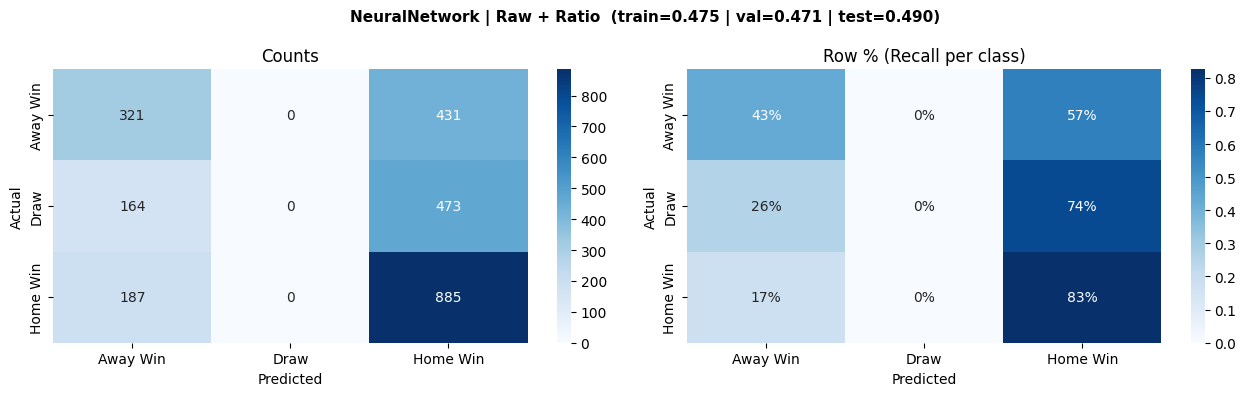

              precision    recall  f1-score   support

    Away Win      0.478     0.427     0.451       752
        Draw      0.000     0.000     0.000       637
    Home Win      0.495     0.826     0.619      1072

    accuracy                          0.490      2461
   macro avg      0.324     0.417     0.357      2461
weighted avg      0.361     0.490     0.407      2461

  Per-class recall: Away=42.7%  Draw=0.0%  Home=82.6%
-----------------------------------------------------------------


In [64]:
LABEL_NAMES = ['Away Win', 'Draw', 'Home Win']
# Expected class distribution from training data (for reference)
EXPECTED_DIST = {'Away Win': 0.30, 'Draw': 0.26, 'Home Win': 0.44}

print('=' * 65)
print('CLASS DISTRIBUTION OF PREDICTIONS (target: ~30% Away, ~26% Draw, ~44% Home)')
print('=' * 65)

for row in results:
    X_test, y_test = row['_X_test'], row['_y_test']

    # Load saved model to get the pipeline (ensures what we evaluate = what was saved)
    safe      = row['Feature Set'].replace(' ','_').replace('(','').replace(')','').replace('+','')
    path      = MODEL_SAVE_DIR / f"{row['Model']}_{safe}_{FEATURE_VERSION}.pkl"
    pipeline, feat_cols, _, _ = load_model_bundle(path)
    preds     = pipeline.predict(X_test)

    away = (preds == 0).mean() * 100
    draw = (preds == 1).mean() * 100
    home = (preds == 2).mean() * 100
    flag = '⚠️ ' if abs(draw/100 - EXPECTED_DIST['Draw']) > 0.10 else '✓ '
    print(f"{flag}{row['Model']:15s} | {row['Feature Set']:18s} | "
          f"Away={away:.1f}%  Draw={draw:.1f}%  Home={home:.1f}%")

print()
print('=' * 65)
print('CONFUSION MATRICES')
print('=' * 65)

for row in results:
    X_test, y_test = row['_X_test'], row['_y_test']
    safe      = row['Feature Set'].replace(' ','_').replace('(','').replace(')','').replace('+','')
    path      = MODEL_SAVE_DIR / f"{row['Model']}_{safe}_{FEATURE_VERSION}.pkl"
    pipeline, feat_cols, _, _ = load_model_bundle(path)
    preds     = pipeline.predict(X_test)

    cm      = confusion_matrix(y_test, preds, labels=[0, 1, 2])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(
        f"{row['Model']} | {row['Feature Set']}  "
        f"(train={row['Train Acc']:.3f} | val={row['Val Acc']:.3f} | test={row['Test Acc']:.3f})",
        fontsize=11, fontweight='bold'
    )

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
    axes[0].set(title='Counts', ylabel='Actual', xlabel='Predicted')

    sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
    axes[1].set(title='Row % (Recall per class)', ylabel='Actual', xlabel='Predicted')

    plt.tight_layout()
    plt.show()

    per_class = cm.diagonal() / cm.sum(axis=1)
    print(classification_report(y_test, preds, target_names=LABEL_NAMES, digits=3))
    print(f"  Per-class recall: Away={per_class[0]:.1%}  Draw={per_class[1]:.1%}  Home={per_class[2]:.1%}")
    print('-' * 65)

#### 8. Generate Submission

In [65]:
# ── Select best model ─────────────────────────────────────────────────────────
# Change these to whichever run you want to submit
BEST_MODEL_NAME  = results_df.iloc[0]['Model']
BEST_FEATURE_SET = results_df.iloc[0]['Feature Set']
print(f'Submitting: {BEST_MODEL_NAME} | {BEST_FEATURE_SET}')

# ── Load test data ────────────────────────────────────────────────────────────
test_raw = {
    'home_team':   pd.read_csv('../data/Test_Data/test_home_team_statistics_df.csv'),
    'away_team':   pd.read_csv('../data/Test_Data/test_away_team_statistics_df.csv'),
    'home_player': pd.read_csv('../data/Test_Data/test_home_player_statistics_df.csv'),
    'away_player': pd.read_csv('../data/Test_Data/test_away_player_statistics_df.csv'),
    'scores':      pd.read_csv('../data/Y_test_random.csv'),
}

# ── Build test feature matrix (mirrors training pipeline) ─────────────────────
test_master = build_master(test_raw, TEAM_FEATURES, PLAYER_FEATURES, include_target=False)
print(f'✓ test_master: {test_master.shape[0]} rows × {test_master.shape[1]} cols')

# ── Load best model ───────────────────────────────────────────────────────────
safe      = BEST_FEATURE_SET.replace(' ','_').replace('(','').replace(')','').replace('+','')
path      = MODEL_SAVE_DIR / f'{BEST_MODEL_NAME}_{safe}_{FEATURE_VERSION}.pkl'
best_pipe, feat_cols,_,_ = load_model_bundle(path)

missing = [c for c in feat_cols if c not in test_master.columns]
assert not missing, f'⚠️  {len(missing)} feature columns missing from test data: {missing}'

# ── Predict & build submission ────────────────────────────────────────────────
preds = best_pipe.predict(test_master[feat_cols])

submission = pd.DataFrame({
    'ID':        test_master['ID'],
    'HOME_WINS': (preds == 2).astype(int),
    'DRAW':      (preds == 1).astype(int),
    'AWAY_WINS': (preds == 0).astype(int),
})

assert (submission[['HOME_WINS','DRAW','AWAY_WINS']].sum(axis=1) == 1).all(), \
    '⚠️  Each row must have exactly one winner!'

out_dir  = Path('submissions')
out_dir.mkdir(exist_ok=True)
out_path = out_dir / f'submission_{BEST_MODEL_NAME}_{FEATURE_VERSION}.csv'
submission.to_csv(out_path, index=False)

print(f'\n✓ Submission saved → {out_path}')
print(f'  Rows: {len(submission)}')
print(f"  Away={submission['AWAY_WINS'].mean()*100:.1f}%  "
      f"Draw={submission['DRAW'].mean()*100:.1f}%  "
      f"Home={submission['HOME_WINS'].mean()*100:.1f}%")
submission.head()

Submitting: NeuralNetwork | Raw + Ratio
✓ build_master: 25368 rows × 134 cols
✓ test_master: 25368 rows × 134 cols
  [bundle] NeuralNetwork  v3  | 98 features | metrics={'train': np.float64(0.475243996063394), 'val': np.float64(0.47154862292015104), 'test': 0.4900446972775295}

✓ Submission saved → submissions\submission_NeuralNetwork_v3.csv
  Rows: 25368
  Away=27.5%  Draw=0.0%  Home=72.5%


,ID,HOME_WINS,DRAW,AWAY_WINS
0,12303,1,0,0
1,12304,0,0,1
2,12305,1,0,0
3,12306,1,0,0
4,12307,1,0,0
